DBiT-seq SpatialGlue-Style Multimodal Integration Notebook

This script is organized in notebook-style cells for easy import into VS Code or Jupyter.
It adapts the earlier SpatialGlue-style workflow to DBiT-seq-style spatial multi-omics data stored as `.tsv.gz` matrices.


In [ ]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scanpy as sc
import anndata as ad
import re

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy
from scipy.spatial.distance import cdist, jensenshannon
from scipy.optimize import linear_sum_assignment

import harmonypy as hm
from torch_geometric.nn import GCNConv


from SpatialGlueBatchAware import SpatialGlueMini, train_model

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path("../Data/GSE137986_RAW")   # change if needed
OUT_DIR = Path("./outputs_dbit")
FIG_DIR = OUT_DIR / "figures"
EMBED_DIR = OUT_DIR / "embeddings"
MODEL_DIR = OUT_DIR / "models"
TABLE_DIR = OUT_DIR / "tables"

for d in [FIG_DIR, EMBED_DIR, MODEL_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SAMPLE_CONFIG = [
    {
        "name": "0702",
        "rna": "GSM4189613_0702cL.tsv.gz",
        "protein": "GSM4202307_0702aL.tsv.gz",
    },
    {
        "name": "0713",
        "rna": "GSM4189614_0713cL.tsv.gz",
        "protein": "GSM4202308_0713aL.tsv.gz",
    },
]

N_RNA_HVG = 2000
RNA_PCS = 20
PROT_PCS = 20
SPATIAL_K = 6
FEATURE_K = 20

HIDDEN_DIM = 64
LATENT_DIM = 32
DROPOUT = 0.1

EPOCHS = 600
LR = 1e-3
LAMBDA_CORR = 1.0
LAMBDA_BATCH = 0.1

N_CLUSTERS = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)
print("Data directory:", DATA_DIR.resolve())


DBIT_SPOT_SIZE = 4
DBIT_EXPR_SPOT_SIZE = 1


Using device: cuda
Data directory: C:\Users\imoha\OneDrive\Computational Biology SpatialGLUE\Data\GSE137986_RAW


Helpers for DBiT-seq loading and preprocessing


In [21]:
def read_dbit_tsv(path: Path) -> pd.DataFrame:
    """
    Read DBiT TSV.GZ into a raw dataframe.
    Keeps the first column as index.
    """
    df = pd.read_csv(path, sep="\t", compression="gzip")
    first_col = df.columns[0]
    df = df.rename(columns={first_col: "feature"})
    df = df.set_index("feature")
    return df


def is_dbit_cell_id(x):
    """
    DBiT cell IDs usually look like '12x34' or similar integer x integer format.
    """
    return bool(re.fullmatch(r"\d+x\d+", str(x)))


def parse_dbit_cell_ids(cell_ids):
    coords = []
    for cid in cell_ids:
        s = str(cid)
        if not is_dbit_cell_id(s):
            raise ValueError(f"Could not parse DBiT cell id: {cid}")
        x, y = s.split("x")
        coords.append([float(x), -float(y)])
    return np.asarray(coords, dtype=np.float32)


def make_adata_from_dbit(df_counts: pd.DataFrame, modality: str, sample_name: str) -> ad.AnnData:
    """
    Build AnnData while automatically detecting whether:
    - rows are features and columns are DBiT cell IDs
    OR
    - rows are DBiT cell IDs and columns are features
    """
    row_is_cells = np.mean([is_dbit_cell_id(x) for x in df_counts.index[: min(50, len(df_counts.index))]]) > 0.5
    col_is_cells = np.mean([is_dbit_cell_id(x) for x in df_counts.columns[: min(50, len(df_counts.columns))]]) > 0.5

    if col_is_cells and not row_is_cells:
        # expected case: rows=features, cols=cells
        X = df_counts.T.copy()
    elif row_is_cells and not col_is_cells:
        # already rows=cells, cols=features
        X = df_counts.copy()
    else:
        raise ValueError(
            "Could not determine DBiT matrix orientation. "
            f"row_is_cells={row_is_cells}, col_is_cells={col_is_cells}. "
            "Inspect the first few row/column labels."
        )

    adata = ad.AnnData(X=X.values.astype(np.float32))
    adata.obs_names = X.index.astype(str)
    adata.var_names = X.columns.astype(str)
    adata.obs["sample"] = sample_name
    adata.obs["modality"] = modality
    adata.obsm["spatial"] = parse_dbit_cell_ids(adata.obs_names)
    return adata


def preprocess_rna_adata(adata: ad.AnnData, n_hvg=2000, n_pcs=30) -> ad.AnnData:
    adata = adata.copy()
    sc.pp.filter_cells(adata, min_counts=10)
    sc.pp.filter_genes(adata, min_cells=3)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    n_hvg = min(n_hvg, adata.n_vars)
    sc.pp.highly_variable_genes(adata, n_top_genes=n_hvg, flavor="seurat")
    if "highly_variable" in adata.var.columns and adata.var["highly_variable"].sum() > 0:
        adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata, max_value=10)
    n_pcs = min(n_pcs, adata.n_vars, adata.n_obs)
    sc.tl.pca(adata, n_comps=n_pcs, svd_solver="arpack")
    adata.obsm["feat"] = adata.obsm["X_pca"].astype(np.float32)
    return adata


def preprocess_protein_adata(adata: ad.AnnData, n_pcs=20) -> ad.AnnData:
    adata = adata.copy()
    sc.pp.filter_cells(adata, min_counts=1)
    sc.pp.filter_genes(adata, min_cells=1)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.scale(adata, max_value=10)
    n_pcs = min(n_pcs, adata.n_vars, adata.n_obs)
    if n_pcs >= 2:
        sc.tl.pca(adata, n_comps=n_pcs, svd_solver="arpack")
        adata.obsm["feat"] = adata.obsm["X_pca"].astype(np.float32)
    else:
        adata.obsm["feat"] = np.asarray(adata.X, dtype=np.float32)
    return adata


def align_modalities(adata_rna: ad.AnnData, adata_prot: ad.AnnData):
    common = adata_rna.obs_names.intersection(adata_prot.obs_names)
    adata_rna = adata_rna[common].copy()
    adata_prot = adata_prot[common].copy()
    assert np.all(adata_rna.obs_names == adata_prot.obs_names)
    return adata_rna, adata_prot


def load_one_dbit_sample(rna_path: Path, prot_path: Path, sample_name: str):
    print(f"Loading {sample_name}")
    rna_df = read_dbit_tsv(rna_path)
    prot_df = read_dbit_tsv(prot_path)
    adata_rna = make_adata_from_dbit(rna_df, modality="rna", sample_name=sample_name)
    adata_prot = make_adata_from_dbit(prot_df, modality="protein", sample_name=sample_name)
    adata_rna, adata_prot = align_modalities(adata_rna, adata_prot)
    adata_rna = preprocess_rna_adata(adata_rna, n_hvg=N_RNA_HVG, n_pcs=RNA_PCS)
    adata_prot = preprocess_protein_adata(adata_prot, n_pcs=PROT_PCS)
    return adata_rna, adata_prot


Graph helpers


In [22]:
def knn_edge_index(X, k):
    nbrs = NearestNeighbors(n_neighbors=min(k + 1, len(X))).fit(X)
    indices = nbrs.kneighbors(X, return_distance=False)
    edges = []
    for i in range(X.shape[0]):
        for j in indices[i, 1:]:
            edges.append([i, j])
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return edge_index


def offset_edge_index(edge_index, offset):
    return edge_index + offset


SpatialGlue-style model


Load the selected DBiT-seq samples


In [23]:
loaded = {}
for cfg in SAMPLE_CONFIG:
    rna_path = DATA_DIR / cfg["rna"]
    prot_path = DATA_DIR / cfg["protein"]
    if not rna_path.exists():
        raise FileNotFoundError(f"Missing RNA file: {rna_path}")
    if not prot_path.exists():
        raise FileNotFoundError(f"Missing protein file: {prot_path}")
    loaded[cfg["name"]] = load_one_dbit_sample(rna_path, prot_path, cfg["name"])

for sample_name, (adata_rna, adata_prot) in loaded.items():
    print(f"\\n{sample_name}")
    print("RNA:", adata_rna.shape, "feat:", adata_rna.obsm["feat"].shape)
    print("Protein:", adata_prot.shape, "feat:", adata_prot.obsm["feat"].shape)


Loading 0702
Loading 0713
\n0702
RNA: (901, 2000) feat: (901, 20)
Protein: (901, 22) feat: (901, 20)
\n0713
RNA: (1789, 2000) feat: (1789, 20)
Protein: (1789, 22) feat: (1789, 20)


Quick spatial expression check


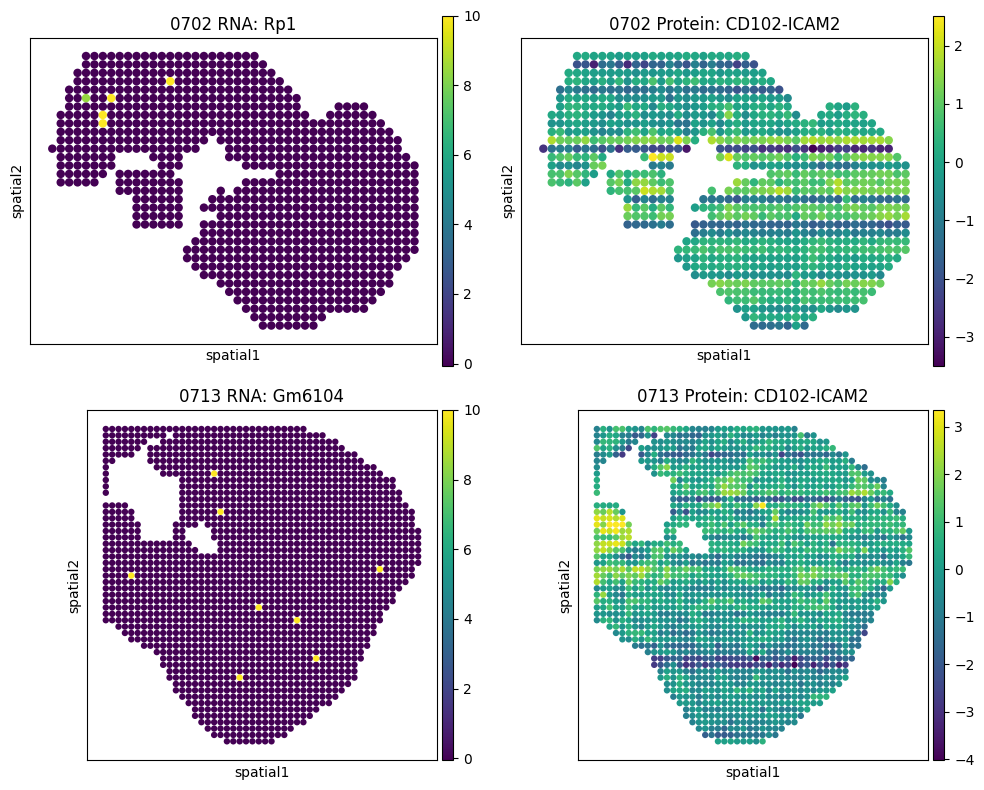

In [29]:

fig, axes = plt.subplots(len(SAMPLE_CONFIG), 2, figsize=(10, 4 * len(SAMPLE_CONFIG)))

if len(SAMPLE_CONFIG) == 1:
    axes = np.array([axes])

for row, cfg in enumerate(SAMPLE_CONFIG):
    sample_name = cfg["name"]
    adata_rna, adata_prot = loaded[sample_name]

    rna_feat = adata_rna.var_names[0]
    prot_feat = adata_prot.var_names[0]

    sc.pl.spatial(
        adata_rna,
        color=rna_feat,
        spot_size=DBIT_EXPR_SPOT_SIZE,
        cmap="viridis",
        ax=axes[row, 0],
        show=False,
        title=f"{sample_name} RNA: {rna_feat}"
    )
    axes[row, 0].set_aspect("equal")

    sc.pl.spatial(
        adata_prot,
        color=prot_feat,
        spot_size=DBIT_EXPR_SPOT_SIZE,
        cmap="viridis",
        ax=axes[row, 1],
        show=False,
        title=f"{sample_name} Protein: {prot_feat}"
    )
    axes[row, 1].set_aspect("equal")

plt.tight_layout()
plt.show()


Build combined multimodal tensors and disconnected graphs


In [6]:
sample_names = []
sample_ids_list = []
X_rna_parts = []
X_prot_parts = []
coords_parts = []
spatial_parts = []
rna_feat_parts = []
prot_feat_parts = []
offset = 0
for sample_idx, cfg in enumerate(SAMPLE_CONFIG):
    sample_name = cfg["name"]
    adata_rna, adata_prot = loaded[sample_name]
    X_rna = adata_rna.obsm["feat"].astype(np.float32)
    X_prot = adata_prot.obsm["feat"].astype(np.float32)
    coords = adata_rna.obsm["spatial"].astype(np.float32)
    X_rna_parts.append(X_rna)
    X_prot_parts.append(X_prot)
    coords_parts.append(coords)
    n = X_rna.shape[0]
    sample_names.extend([sample_name] * n)
    sample_ids_list.extend([sample_idx] * n)
    spatial_local = knn_edge_index(coords, k=SPATIAL_K)
    rna_feat_local = knn_edge_index(X_rna, k=FEATURE_K)
    prot_feat_local = knn_edge_index(X_prot, k=FEATURE_K)
    spatial_parts.append(offset_edge_index(spatial_local, offset))
    rna_feat_parts.append(offset_edge_index(rna_feat_local, offset))
    prot_feat_parts.append(offset_edge_index(prot_feat_local, offset))
    offset += n
X_rna_all = np.concatenate(X_rna_parts, axis=0)
X_prot_all = np.concatenate(X_prot_parts, axis=0)
coords_all = np.vstack(coords_parts)
sample_names = np.asarray(sample_names)
sample_ids = np.asarray(sample_ids_list, dtype=np.int64)
spatial_edge_index = torch.cat(spatial_parts, dim=1)
rna_feature_edge_index = torch.cat(rna_feat_parts, dim=1)
prot_feature_edge_index = torch.cat(prot_feat_parts, dim=1)
print("Combined RNA:", X_rna_all.shape)
print("Combined Protein:", X_prot_all.shape)
print("Combined coords:", coords_all.shape)
print("Samples:", np.unique(sample_names), "counts:", [np.sum(sample_names == s) for s in np.unique(sample_names)])
print("Spatial graph:", spatial_edge_index.shape)
print("RNA feature graph:", rna_feature_edge_index.shape)
print("Protein feature graph:", prot_feature_edge_index.shape)


Combined RNA: (2690, 20)
Combined Protein: (2690, 20)
Combined coords: (2690, 2)
Samples: ['0702' '0713'] counts: [np.int64(901), np.int64(1789)]
Spatial graph: torch.Size([2, 16140])
RNA feature graph: torch.Size([2, 53800])
Protein feature graph: torch.Size([2, 53800])


Train the no-batch and MMD batch-aware models


In [7]:
# ## Train the no-batch and MMD batch-aware models

X_rna_t = torch.tensor(X_rna_all, dtype=torch.float32)
X_prot_t = torch.tensor(X_prot_all, dtype=torch.float32)
sample_ids_t = torch.tensor(sample_ids, dtype=torch.long)

# This model requires the RNA and protein features to have the same dimension
assert X_rna_all.shape[1] == X_prot_all.shape[1], (
    f"Feature dimensions must match for this model: "
    f"RNA={X_rna_all.shape[1]}, Protein={X_prot_all.shape[1]}"
)

in_dim = X_rna_all.shape[1]

# -----------------------------
# No batch correction model
# -----------------------------
model_no_batch = SpatialGlueMini(
    in_dim=in_dim,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    num_modalities=2,
    dropout=DROPOUT
)

model_no_batch = train_model(
    model_no_batch,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    sample_ids=None,
    epochs=EPOCHS,
    lr=LR,
    lambda_corr=LAMBDA_CORR,
    lambda_batch=0.0,
    device=DEVICE
)

model_no_batch.eval()
with torch.no_grad():
    outputs_no_batch = model_no_batch(
        [X_rna_t.to(DEVICE), X_prot_t.to(DEVICE)],
        spatial_edge_index.to(DEVICE),
        [rna_feature_edge_index.to(DEVICE), prot_feature_edge_index.to(DEVICE)]
    )

Z_no_batch = outputs_no_batch["z"].detach().cpu().numpy()

# -----------------------------
# MMD batch-aware model
# -----------------------------
model_batch = SpatialGlueMini(
    in_dim=in_dim,
    hidden_dim=HIDDEN_DIM,
    latent_dim=LATENT_DIM,
    num_modalities=2,
    dropout=DROPOUT
)

model_batch = train_model(
    model_batch,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    sample_ids=sample_ids_t,
    epochs=EPOCHS,
    lr=LR,
    lambda_corr=LAMBDA_CORR,
    lambda_batch=LAMBDA_BATCH,
    device=DEVICE
)

model_batch.eval()
with torch.no_grad():
    outputs_batch = model_batch(
        [X_rna_t.to(DEVICE), X_prot_t.to(DEVICE)],
        spatial_edge_index.to(DEVICE),
        [rna_feature_edge_index.to(DEVICE), prot_feature_edge_index.to(DEVICE)]
    )

Z_batch = outputs_batch["z"].detach().cpu().numpy()

print("Z_no_batch:", Z_no_batch.shape)
print("Z_batch:", Z_batch.shape)

Epoch 0000 | total=13.5192 | recon=7.6719 | corr=5.8473 | batch=0.0000
Epoch 0050 | total=6.9483 | recon=6.6385 | corr=0.3098 | batch=0.0000
Epoch 0100 | total=5.8782 | recon=5.5666 | corr=0.3116 | batch=0.0000
Epoch 0150 | total=5.2230 | recon=4.9431 | corr=0.2799 | batch=0.0000
Epoch 0200 | total=4.7740 | recon=4.4928 | corr=0.2812 | batch=0.0000
Epoch 0250 | total=4.4771 | recon=4.2187 | corr=0.2584 | batch=0.0000
Epoch 0300 | total=4.2456 | recon=3.9993 | corr=0.2463 | batch=0.0000
Epoch 0350 | total=4.0692 | recon=3.8358 | corr=0.2334 | batch=0.0000
Epoch 0400 | total=3.9215 | recon=3.7053 | corr=0.2162 | batch=0.0000
Epoch 0450 | total=3.7804 | recon=3.5693 | corr=0.2111 | batch=0.0000
Epoch 0500 | total=3.6912 | recon=3.4909 | corr=0.2002 | batch=0.0000
Epoch 0550 | total=3.5695 | recon=3.3755 | corr=0.1939 | batch=0.0000
Epoch 0000 | total=13.2409 | recon=8.0069 | corr=5.2336 | batch=0.0040
Epoch 0050 | total=7.0108 | recon=6.6866 | corr=0.3141 | batch=0.1016
Epoch 0100 | total

Harmony on the no-batch latent embedding


In [8]:
def run_harmony_on_latent(Z, sample_names, batch_key="sample", random_state=0, **harmony_kwargs):
    Z = np.asarray(Z, dtype=np.float64)
    meta = pd.DataFrame({batch_key: np.asarray(sample_names)})
    ho = hm.run_harmony(data_mat=Z, meta_data=meta, vars_use=[batch_key], random_state=random_state, **harmony_kwargs)
    Z_corr = np.asarray(ho.Z_corr)
    if Z_corr.shape == Z.shape:
        Z_harmony = Z_corr
    elif Z_corr.shape == (Z.shape[1], Z.shape[0]):
        Z_harmony = Z_corr.T
    else:
        raise ValueError(f"Unexpected Harmony output shape: {Z_corr.shape}")
    return Z_harmony, ho

Z_harmony, harmony_obj = run_harmony_on_latent(Z_no_batch, sample_names, batch_key="sample", theta=2.0, lamb=1.0, sigma=0.1, random_state=SEED)
print("Z_harmony:", Z_harmony.shape)


2026-04-13 03:42:11,394 - harmonypy - INFO - Running Harmony (PyTorch on cuda)
2026-04-13 03:42:11,394 - harmonypy - INFO -   Parameters:
2026-04-13 03:42:11,394 - harmonypy - INFO -     max_iter_harmony: 10
2026-04-13 03:42:11,394 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-13 03:42:11,397 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-13 03:42:11,398 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-13 03:42:11,398 - harmonypy - INFO -     nclust: 90
2026-04-13 03:42:11,398 - harmonypy - INFO -     block_size: 0.05
2026-04-13 03:42:11,398 - harmonypy - INFO -     lamb: [1. 1.]
2026-04-13 03:42:11,398 - harmonypy - INFO -     theta: [2. 2.]
2026-04-13 03:42:11,398 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-13 03:42:11,401 - harmonypy - INFO -     verbose: True
2026-04-13 03:42:11,401 - harmonypy - INFO -     random_state: 42
2026-04-13 03:42:11,401 - harmonypy - INFO -   Data: 32 PCs × 2690 cells
2026-04-13 03:42:11,401 - harmonypy - INFO

Z_harmony: (2690, 32)


Combined latent-space comparison


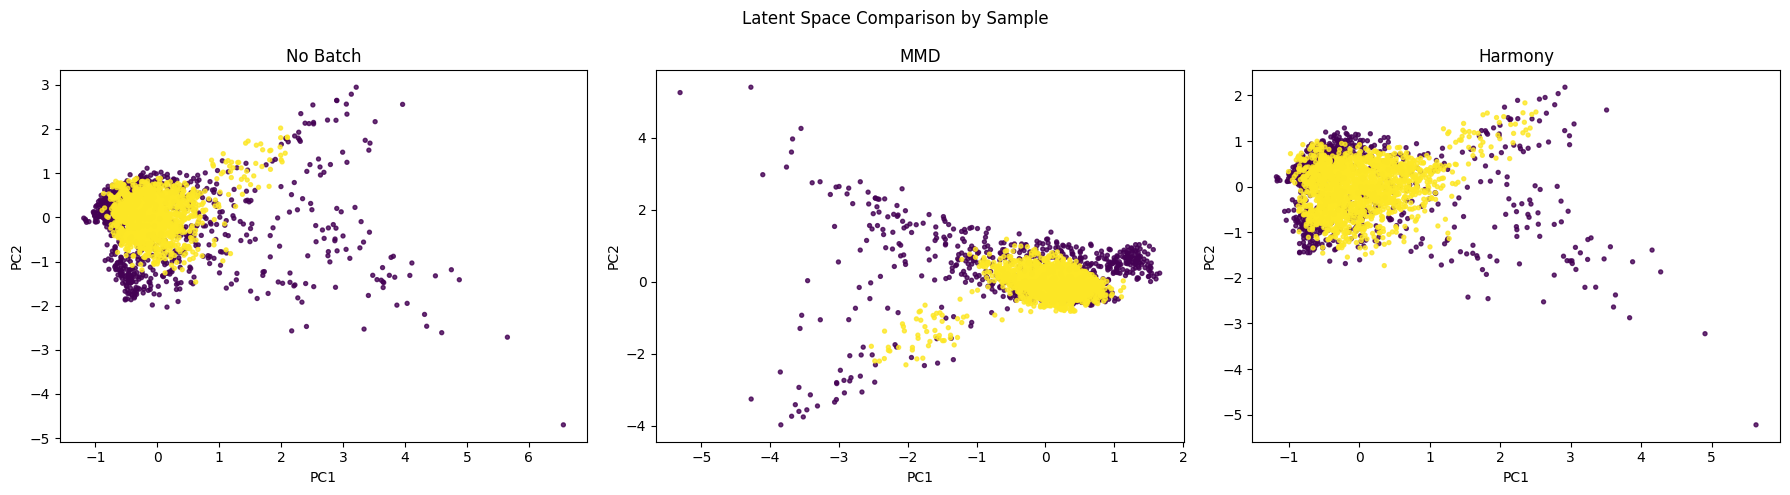

In [9]:
def pca_2d(X):
    return PCA(n_components=2, random_state=SEED).fit_transform(X)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, name, Z in zip(axes, ["No Batch", "MMD", "Harmony"], [Z_no_batch, Z_batch, Z_harmony]):
    Z2 = pca_2d(Z)
    ax.scatter(Z2[:, 0], Z2[:, 1], c=pd.Categorical(sample_names).codes, s=8, alpha=0.8)
    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.suptitle("Latent Space Comparison by Sample")
plt.tight_layout()
plt.savefig(FIG_DIR / "latent_space_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


Spatial clustering comparison


### Note on DBiT spatial plots

DBiT coordinates are integer grid positions, so large `spot_size` values make the plots look like giant overlapping circles. The plotting cells below use much smaller marker sizes and force equal aspect ratio for a readable grid-like layout.

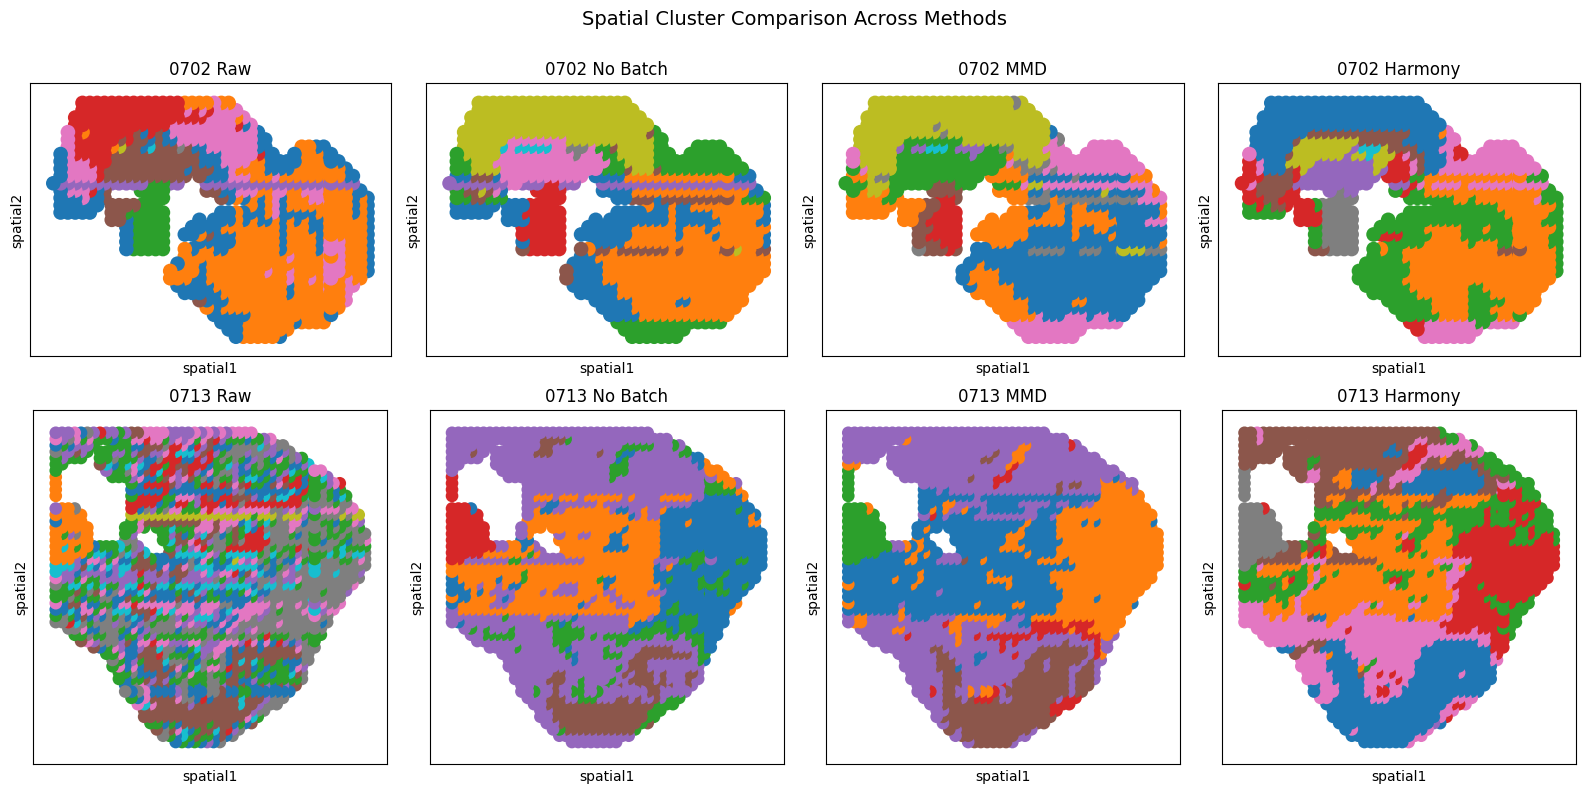

In [30]:

def cluster_embedding(X, n_clusters=10, random_state=0):
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=20)
    labels = km.fit_predict(X)
    return labels, km.cluster_centers_

labels_no_batch, _ = cluster_embedding(Z_no_batch, n_clusters=N_CLUSTERS, random_state=SEED)
labels_batch, _ = cluster_embedding(Z_batch, n_clusters=N_CLUSTERS, random_state=SEED)
labels_harmony, _ = cluster_embedding(Z_harmony, n_clusters=N_CLUSTERS, random_state=SEED)

adata_plot = {}
start = 0
for cfg in SAMPLE_CONFIG:
    sample_name = cfg["name"]
    adata_rna, _ = loaded[sample_name]
    n = adata_rna.n_obs
    end = start + n

    adata_p = adata_rna.copy()
    adata_p.obs["raw_feat_kmeans"] = pd.Categorical(
        KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=20)
        .fit_predict(adata_rna.obsm["feat"]).astype(str)
    )
    adata_p.obs["latent_no_batch"] = pd.Categorical(labels_no_batch[start:end].astype(str))
    adata_p.obs["latent_batch"] = pd.Categorical(labels_batch[start:end].astype(str))
    adata_p.obs["latent_harmony"] = pd.Categorical(labels_harmony[start:end].astype(str))
    adata_plot[sample_name] = adata_p
    start = end

fig, axes = plt.subplots(len(SAMPLE_CONFIG), 4, figsize=(16, 4 * len(SAMPLE_CONFIG)))

if len(SAMPLE_CONFIG) == 1:
    axes = np.array([axes])

for row, cfg in enumerate(SAMPLE_CONFIG):
    sample_name = cfg["name"]
    adata_p = adata_plot[sample_name]

    for col, color, title in [
        (0, "raw_feat_kmeans", f"{sample_name} Raw"),
        (1, "latent_no_batch", f"{sample_name} No Batch"),
        (2, "latent_batch", f"{sample_name} MMD"),
        (3, "latent_harmony", f"{sample_name} Harmony"),
    ]:
        sc.pl.spatial(
            adata_p,
            color=color,
            spot_size=DBIT_SPOT_SIZE,
            ax=axes[row, col],
            show=False,
            title=title,
            legend_loc=None
        )
        axes[row, col].set_aspect("equal")

plt.suptitle("Spatial Cluster Comparison Across Methods", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "spatial_cluster_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


Quantitative evaluation helpers


In [11]:
def batch_silhouette_score(embedding, batch_labels):
    embedding = np.asarray(embedding)
    batch_labels = np.asarray(batch_labels)
    return silhouette_score(embedding, batch_labels)

def batch_entropy_mixing_score(embedding, batch_labels, k=30):
    embedding = np.asarray(embedding)
    batch_labels = np.asarray(batch_labels)
    nbrs = NearestNeighbors(n_neighbors=min(k + 1, len(embedding))).fit(embedding)
    indices = nbrs.kneighbors(embedding, return_distance=False)[:, 1:]
    unique_batches = np.unique(batch_labels)
    entropies = []
    for neigh_idx in indices:
        neigh_batches = batch_labels[neigh_idx]
        counts = np.array([(neigh_batches == b).sum() for b in unique_batches], dtype=float)
        probs = counts / counts.sum()
        entropies.append(entropy(probs, base=2))
    return np.mean(entropies)

def normalized_batch_entropy_score(embedding, batch_labels, k=30):
    embedding = np.asarray(embedding)
    batch_labels = np.asarray(batch_labels)
    nbrs = NearestNeighbors(n_neighbors=min(k + 1, len(embedding))).fit(embedding)
    indices = nbrs.kneighbors(embedding, return_distance=False)[:, 1:]
    unique_batches = np.unique(batch_labels)
    max_entropy = np.log2(len(unique_batches))
    entropies = []
    for neigh_idx in indices:
        neigh_batches = batch_labels[neigh_idx]
        counts = np.array([(neigh_batches == b).sum() for b in unique_batches], dtype=float)
        probs = counts / counts.sum()
        entropies.append(entropy(probs, base=2) / max_entropy)
    return np.mean(entropies)

def evaluate_batch_mixing(embedding, batch_labels, k=30):
    return {"batch_silhouette": batch_silhouette_score(embedding, batch_labels), "batch_entropy": batch_entropy_mixing_score(embedding, batch_labels, k=k), "normalized_batch_entropy": normalized_batch_entropy_score(embedding, batch_labels, k=k)}

def spatial_coherence_score(cluster_labels, coords, sample_names, k=6):
    cluster_labels = np.asarray(cluster_labels)
    coords = np.asarray(coords)
    sample_names = np.asarray(sample_names)
    per_sample_scores = {}
    all_scores = []
    for sample in np.unique(sample_names):
        idx = np.where(sample_names == sample)[0]
        coords_s = coords[idx]
        labels_s = cluster_labels[idx]
        nbrs = NearestNeighbors(n_neighbors=min(k + 1, len(idx))).fit(coords_s)
        neighbor_idx = nbrs.kneighbors(coords_s, return_distance=False)[:, 1:]
        same_cluster = []
        for i in range(len(idx)):
            neigh_labels = labels_s[neighbor_idx[i]]
            same_cluster.append(np.mean(neigh_labels == labels_s[i]))
        score = float(np.mean(same_cluster))
        per_sample_scores[sample] = score
        all_scores.extend(same_cluster)
    return float(np.mean(all_scores)), per_sample_scores

def cluster_distribution_by_sample(cluster_labels, sample_names, n_clusters):
    df = pd.DataFrame({"sample": sample_names, "cluster": cluster_labels})
    counts = pd.crosstab(df["sample"], df["cluster"])
    counts = counts.reindex(columns=range(n_clusters), fill_value=0)
    props = counts.div(counts.sum(axis=1), axis=0)
    return props

def sample_distribution_jsd(cluster_labels, sample_names, n_clusters):
    props = cluster_distribution_by_sample(cluster_labels, sample_names, n_clusters)
    if props.shape[0] != 2:
        return np.nan
    p = props.iloc[0].values
    q = props.iloc[1].values
    return float(jensenshannon(p, q, base=2))

def matched_centroid_distance(X, cluster_labels, sample_names, n_clusters):
    X = np.asarray(X)
    cluster_labels = np.asarray(cluster_labels)
    sample_names = np.asarray(sample_names)
    unique_samples = np.unique(sample_names)
    if len(unique_samples) != 2:
        return np.nan
    sample_a, sample_b = unique_samples[0], unique_samples[1]
    idx_a = np.where(sample_names == sample_a)[0]
    idx_b = np.where(sample_names == sample_b)[0]
    X_a, y_a = X[idx_a], cluster_labels[idx_a]
    X_b, y_b = X[idx_b], cluster_labels[idx_b]
    centroids_a = []
    centroids_b = []
    for c in range(n_clusters):
        has_a = np.any(y_a == c)
        has_b = np.any(y_b == c)
        if has_a and has_b:
            centroids_a.append(X_a[y_a == c].mean(axis=0))
            centroids_b.append(X_b[y_b == c].mean(axis=0))
    if len(centroids_a) < 2:
        return np.nan
    centroids_a = np.vstack(centroids_a)
    centroids_b = np.vstack(centroids_b)
    dist_mat = cdist(centroids_a, centroids_b, metric="euclidean")
    row_ind, col_ind = linear_sum_assignment(dist_mat)
    return float(dist_mat[row_ind, col_ind].mean())

def pairwise_method_agreement(cluster_dict):
    methods = list(cluster_dict.keys())
    ari_mat = pd.DataFrame(index=methods, columns=methods, dtype=float)
    nmi_mat = pd.DataFrame(index=methods, columns=methods, dtype=float)
    for m1 in methods:
        for m2 in methods:
            ari_mat.loc[m1, m2] = adjusted_rand_score(cluster_dict[m1], cluster_dict[m2])
            nmi_mat.loc[m1, m2] = normalized_mutual_info_score(cluster_dict[m1], cluster_dict[m2])
    return ari_mat, nmi_mat


Run the full quantitative comparison


In [12]:
X_concat_all = np.concatenate([X_rna_all, X_prot_all], axis=1)
embeddings = {"Raw RNA": X_rna_all, "Raw RNA+Protein": X_concat_all, "No Batch Correction": Z_no_batch, "MMD Batch Correction": Z_batch, "Harmony Correction": Z_harmony}
cluster_labels_dict = {}
batch_rows = []
struct_rows = []
for method_name, X in embeddings.items():
    labels, _ = cluster_embedding(X, n_clusters=N_CLUSTERS, random_state=SEED)
    cluster_labels_dict[method_name] = labels
    bm = evaluate_batch_mixing(X, sample_names, k=30)
    batch_rows.append({"method": method_name, **bm})
    spatial_overall, spatial_by_sample = spatial_coherence_score(labels, coords_all, sample_names, k=SPATIAL_K)
    struct_rows.append({
        "method": method_name,
        "spatial_coherence_overall": spatial_overall,
        **{f"spatial_coherence_{s}": spatial_by_sample.get(s, np.nan) for s in np.unique(sample_names)},
        "sample_cluster_jsd": sample_distribution_jsd(labels, sample_names, N_CLUSTERS),
        "sample_centroid_distance": matched_centroid_distance(X, labels, sample_names, N_CLUSTERS),
    })
batch_df = pd.DataFrame(batch_rows).sort_values("method").reset_index(drop=True)
struct_df = pd.DataFrame(struct_rows).sort_values("method").reset_index(drop=True)
print("Batch mixing metrics")
display(batch_df.round(4))
print("Structural metrics")
display(struct_df.round(4))


Batch mixing metrics


,method,batch_silhouette,batch_entropy,normalized_batch_entropy
0,Harmony Correction,0.0882,0.2628,0.2628
1,MMD Batch Correction,0.1184,0.2205,0.2205
2,No Batch Correction,0.1274,0.1870,0.1870
3,Raw RNA,0.0788,0.5573,0.5573
4,Raw RNA+Protein,0.0654,0.5352,0.5352


Structural metrics


,method,spatial_coherence_overall,spatial_coherence_0702,spatial_coherence_0713,sample_cluster_jsd,sample_centroid_distance
0,Harmony Correction,0.7232,0.7392,0.7152,0.3198,0.8371
1,MMD Batch Correction,0.7581,0.7183,0.7782,0.4375,0.8195
2,No Batch Correction,0.7243,0.7325,0.7201,0.4585,0.8994
3,Raw RNA,0.5320,0.6123,0.4916,0.3898,5.2840
4,Raw RNA+Protein,0.5117,0.6069,0.4638,0.3001,5.0778


Method agreement matrices


In [13]:
ari_mat, nmi_mat = pairwise_method_agreement(cluster_labels_dict)
print("ARI agreement")
display(ari_mat.round(4))
print("NMI agreement")
display(nmi_mat.round(4))


ARI agreement


,Raw RNA,Raw RNA+Protein,No Batch Correction,MMD Batch Correction,Harmony Correction
Raw RNA,1.0000,0.3903,0.1618,0.1508,0.1340
Raw RNA+Protein,0.3903,1.0000,0.2473,0.2526,0.2513
No Batch Correction,0.1618,0.2473,1.0000,0.6065,0.3887
MMD Batch Correction,0.1508,0.2526,0.6065,1.0000,0.4162
Harmony Correction,0.1340,0.2513,0.3887,0.4162,1.0000


NMI agreement


,Raw RNA,Raw RNA+Protein,No Batch Correction,MMD Batch Correction,Harmony Correction
Raw RNA,1.0000,0.5208,0.3057,0.2736,0.2630
Raw RNA+Protein,0.5208,1.0000,0.3784,0.3524,0.3366
No Batch Correction,0.3057,0.3784,1.0000,0.6374,0.5436
MMD Batch Correction,0.2736,0.3524,0.6374,1.0000,0.5282
Harmony Correction,0.2630,0.3366,0.5436,0.5282,1.0000


Combined metric plots


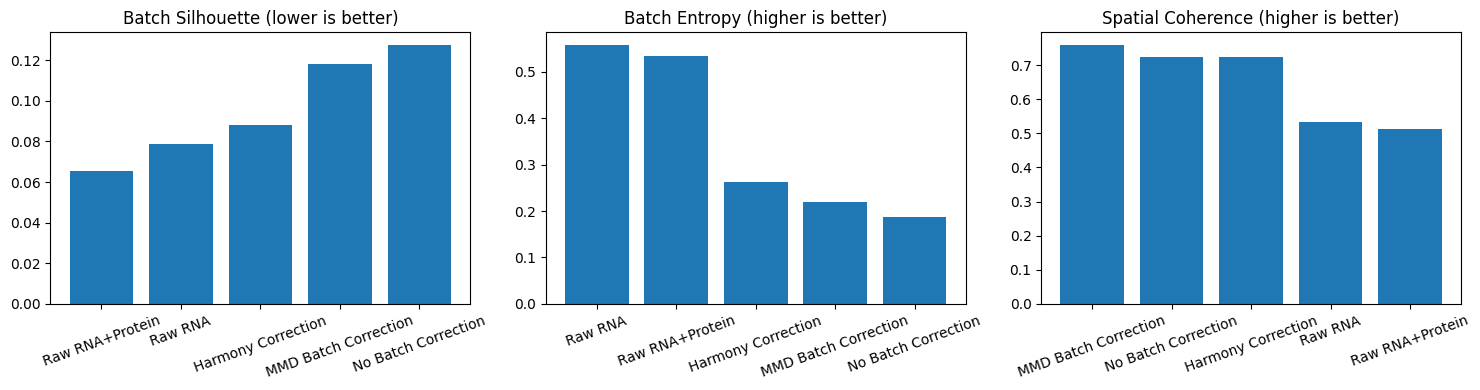

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_df = batch_df.sort_values("batch_silhouette", ascending=True)
axes[0].bar(plot_df["method"], plot_df["batch_silhouette"])
axes[0].set_title("Batch Silhouette (lower is better)")
axes[0].tick_params(axis="x", rotation=20)
plot_df = batch_df.sort_values("batch_entropy", ascending=False)
axes[1].bar(plot_df["method"], plot_df["batch_entropy"])
axes[1].set_title("Batch Entropy (higher is better)")
axes[1].tick_params(axis="x", rotation=20)
plot_df = struct_df.sort_values("spatial_coherence_overall", ascending=False)
axes[2].bar(plot_df["method"], plot_df["spatial_coherence_overall"])
axes[2].set_title("Spatial Coherence (higher is better)")
axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "metric_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


PCA comparison across all methods


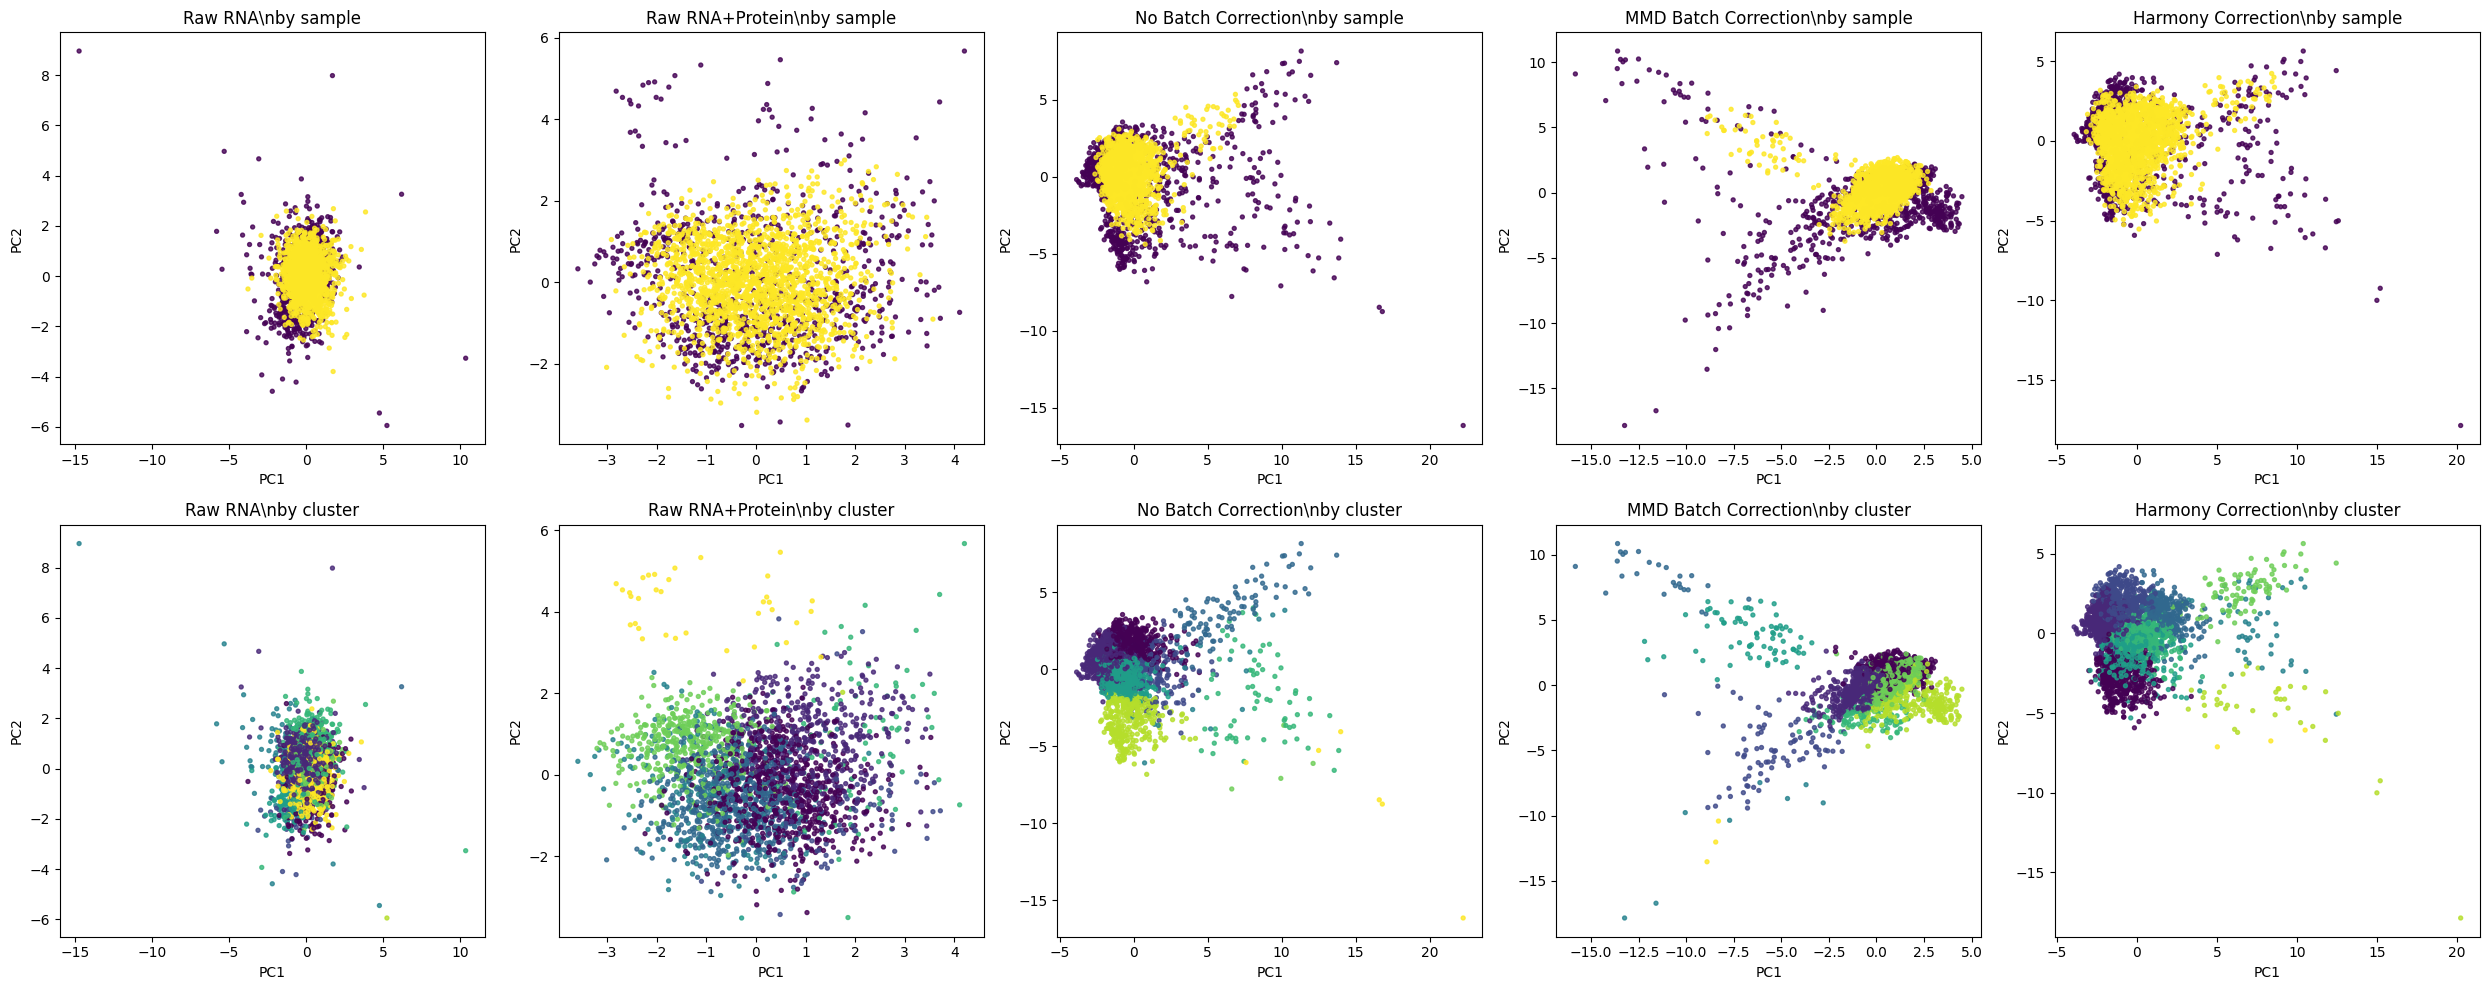

In [15]:
methods_for_pca = list(embeddings.keys())
fig, axes = plt.subplots(2, len(methods_for_pca), figsize=(5 * len(methods_for_pca), 10))
for col_idx, method_name in enumerate(methods_for_pca):
    X = embeddings[method_name]
    Z2 = PCA(n_components=2, random_state=SEED).fit_transform(StandardScaler().fit_transform(X))
    axes[0, col_idx].scatter(Z2[:, 0], Z2[:, 1], c=pd.Categorical(sample_names).codes, s=8, alpha=0.8)
    axes[0, col_idx].set_title(f"{method_name}\\nby sample")
    axes[0, col_idx].set_xlabel("PC1")
    axes[0, col_idx].set_ylabel("PC2")
    axes[1, col_idx].scatter(Z2[:, 0], Z2[:, 1], c=cluster_labels_dict[method_name], s=8, alpha=0.8)
    axes[1, col_idx].set_title(f"{method_name}\\nby cluster")
    axes[1, col_idx].set_xlabel("PC1")
    axes[1, col_idx].set_ylabel("PC2")
plt.tight_layout()
plt.savefig(FIG_DIR / "pca_comparison_all_methods.png", dpi=300, bbox_inches="tight")
plt.show()


Cluster composition by sample


In [16]:
cluster_comp_tables = {}
for method_name, labels in cluster_labels_dict.items():
    props = cluster_distribution_by_sample(labels, sample_names, N_CLUSTERS).round(4)
    cluster_comp_tables[method_name] = props
    print(f"\\nCluster composition by sample — {method_name}")
    display(props)
    props.to_csv(TABLE_DIR / f"{method_name.lower().replace(' ', '_')}_cluster_composition.csv")


\nCluster composition by sample — Raw RNA


cluster,0,1,2,3,4,5,6,7,8,9
sample,,,,,,,,,,
0702,0.1276,0.1354,0.0388,0.0011,0.0877,0.1154,0.1809,0.0533,0.0011,0.2586
0713,0.0632,0.4332,0.0006,0.0000,0.0056,0.0257,0.1224,0.0207,0.0000,0.3287


\nCluster composition by sample — Raw RNA+Protein


cluster,0,1,2,3,4,5,6,7,8,9
sample,,,,,,,,,,
0702,0.1398,0.1432,0.0533,0.2575,0.1243,0.0011,0.0921,0.1487,0.0011,0.0388
0713,0.3158,0.1845,0.0207,0.2342,0.0654,0.0000,0.0084,0.1710,0.0000,0.0000


\nCluster composition by sample — No Batch Correction


cluster,0,1,2,3,4,5,6,7,8,9
sample,,,,,,,,,,
0702,0.1543,0.3219,0.1077,0.0511,0.0388,0.0477,0.0777,0.0044,0.1898,0.0067
0713,0.1817,0.2174,0.0872,0.0274,0.0000,0.4080,0.0000,0.0000,0.0783,0.0000


\nCluster composition by sample — MMD Batch Correction


cluster,0,1,2,3,4,5,6,7,8,9
sample,,,,,,,,,,
0702,0.3230,0.1498,0.0988,0.0289,0.0089,0.0255,0.1188,0.0488,0.1942,0.0033
0713,0.2543,0.2180,0.0000,0.0000,0.0000,0.0279,0.0341,0.3438,0.1219,0.0000


\nCluster composition by sample — Harmony Correction


cluster,0,1,2,3,4,5,6,7,8,9
sample,,,,,,,,,,
0702,0.1554,0.2808,0.2120,0.0511,0.0522,0.0599,0.1021,0.0411,0.0411,0.0044
0713,0.1828,0.1778,0.1347,0.1481,0.0006,0.1420,0.1856,0.0285,0.0000,0.0000


Save outputs


In [17]:
np.save(EMBED_DIR / "Z_no_batch.npy", Z_no_batch)
np.save(EMBED_DIR / "Z_batch.npy", Z_batch)
np.save(EMBED_DIR / "Z_harmony.npy", Z_harmony)
for method_name, labels in cluster_labels_dict.items():
    np.save(EMBED_DIR / f"{method_name.lower().replace(' ', '_')}_labels.npy", labels)
torch.save(model_no_batch.state_dict(), MODEL_DIR / "model_no_batch.pt")
torch.save(model_batch.state_dict(), MODEL_DIR / "model_batch.pt")
batch_df.to_csv(TABLE_DIR / "batch_metrics.csv", index=False)
struct_df.to_csv(TABLE_DIR / "structural_metrics.csv", index=False)
ari_mat.to_csv(TABLE_DIR / "ari_agreement.csv")
nmi_mat.to_csv(TABLE_DIR / "nmi_agreement.csv")
print("Saved outputs to:", OUT_DIR.resolve())


Saved outputs to: C:\Users\imoha\OneDrive\Computational Biology SpatialGLUE\Project\outputs_dbit
